In [2]:
#Load the given Banknote authentication dataset.  

import pandas as pd 

data = pd.read_csv ('banknote_authentication_dataset.csv')
print(data)




            V1        V2
0     3.621600   8.66610
1     4.545900   8.16740
2     3.866000  -2.63830
3     3.456600   9.52280
4     0.329240  -4.45520
5     4.368400   9.67180
6     3.591200   3.01290
7     2.092200  -6.81000
8     3.203200   5.75880
9     1.535600   9.17720
10    1.224700   8.77790
11    3.989900  -2.70660
12    1.899300   7.66250
13   -1.576800  10.84300
14    3.404000   8.72610
15    4.676500  -3.38950
16    2.671900   3.06460
17    0.803550   2.84730
18    1.447900  -4.87940
19    5.242300  11.02720
20    5.786700   7.89020
21    0.329200  -4.45520
22    3.936200  10.16220
23    0.935840   8.88550
24    4.433800   9.88700
25    0.705700  -5.49810
26    1.143200  -3.74130
27   -0.382140   8.39090
28    6.563300   9.81870
29    4.890600  -3.35840
...        ...       ...
1342 -1.747900  -5.82300
1343 -0.959230  -6.71280
1344  1.345100   0.23589
1345  2.227900   4.09510
1346  1.257200   4.87310
1347 -5.385700   9.12140
1348 -2.978600   2.34450
1349 -1.585100  -2.15620


In [3]:
#Step 2: Calculate statistical measures, e.g. mean and standard deviation. 
data.describe()

,V1,V2
count,1372.000000,1372.000000
mean,0.433735,1.922353
std,2.842763,5.869047
min,-7.042100,-13.773100
25%,-1.773000,-1.708200
50%,0.496180,2.319650
75%,2.821475,6.814625
max,6.824800,12.951600


In [4]:
#Step 3: Visualise your data as you consider fit. 
import matplotlib.pyplot as plt


plt.scatter(data['V1'], data['V2'], alpha= 0.25)
plt.xlabel('V1')
plt.ylabel('V2')
plt.show()



<Figure size 640x480 with 1 Axes>

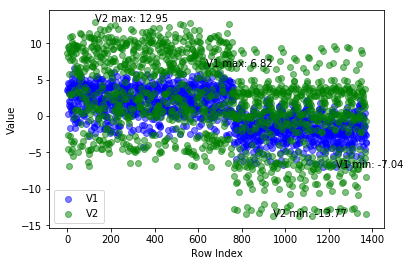

In [7]:
# adding color to the graph to visually compar the two dimensions
plt.scatter(data.index, data['V1'], color= 'blue', alpha= 0.50, label='V1')
plt.scatter(data.index, data['V2'], color= 'green', alpha=0.5, label= 'V2')
plt.xlabel('Row Index')
plt.ylabel('Value')
plt.legend()
v1_max_idx = data['V1'].idxmax()
v1_min_idx = data['V1'].idxmin()
v2_max_idx = data['V2'].idxmax()
v2_min_idx = data['V2'].idxmin()

# add text labels at those points
plt.annotate(f"V1 max: {data['V1'].max():.2f}", (v1_max_idx, data['V1'].max()))
plt.annotate(f"V1 min: {data['V1'].min():.2f}", (v1_min_idx, data['V1'].min()))
plt.annotate(f"V2 max: {data['V2'].max():.2f}", (v2_max_idx, data['V2'].max()))
plt.annotate(f"V2 min: {data['V2'].min():.2f}", (v2_min_idx, data['V2'].min()))

plt.show()

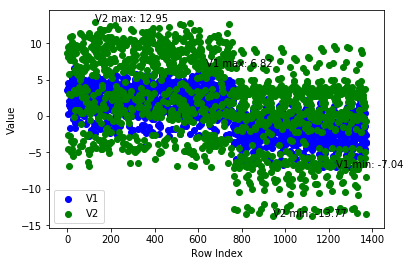

In [5]:
#not not transparent
plt.scatter(data.index, data['V1'], color= 'blue', label='V1')
plt.scatter(data.index, data['V2'], color= 'green', label= 'V2')
plt.xlabel('Row Index')
plt.ylabel('Value')
plt.legend()
v1_max_idx = data['V1'].idxmax()
v1_min_idx = data['V1'].idxmin()
v2_max_idx = data['V2'].idxmax()
v2_min_idx = data['V2'].idxmin()

# add text labels at those points
plt.annotate(f"V1 max: {data['V1'].max():.2f}", (v1_max_idx, data['V1'].max()))
plt.annotate(f"V1 min: {data['V1'].min():.2f}", (v1_min_idx, data['V1'].min()))
plt.annotate(f"V2 max: {data['V2'].max():.2f}", (v2_max_idx, data['V2'].max()))
plt.annotate(f"V2 min: {data['V2'].min():.2f}", (v2_min_idx, data['V2'].min()))

plt.show()

In [6]:
#Step 4: Evaluate if the given dataset is suitable for the K-Means clustering task.
#Step 1 showed us that std 1 for V2 is double of std of V1, so now we have to scale the data 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled =scaler.fit_transform(data[['V1', 'V2']])
print (data_scaled)

[[ 1.12180565  1.14945512]
 [ 1.44706568  1.06445293]
 [ 1.20780971 -0.77735215]
 ...
 [-1.47235682 -2.62164576]
 [-1.40669251 -1.75647104]
 [-1.04712236 -0.43982168]]


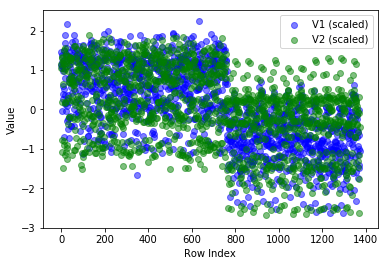

In [18]:
# now lets see it visually scaled
plt.scatter(data.index, data_scaled[:, 0], color='blue', alpha=0.5, label='V1 (scaled)')
plt.scatter(data.index, data_scaled[:, 1], color='green', alpha=0.5, label='V2 (scaled)')
plt.xlabel('Row Index')
plt.ylabel('Value')
plt.legend()
plt.show()

In [7]:
#find the outliers
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (data < lower_bound) | (data > upper_bound)
print(outliers.sum())

V1    0
V2    0
dtype: int64


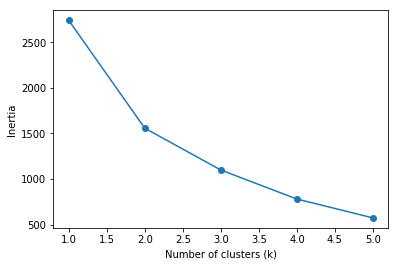

In [8]:
# calculating the outliers NOT eyeballing it
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(data_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 6), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

In [ ]:
#Step 5: Write a short description of the dataset and your evaluation of its suitability for the K-Means clustering task.   

""""

Population: the entire collection of objects of interest.
Sample: a subset of the population observed.
Population parameter: a numerical characteristic of the population, usually unknown.
Sample statistic: a numerical characteristic of the sample used to estimate the population parameter."""